# Begin

In [1]:
import os # @launchit.collect
import sys # @launchit.collect
import socket
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json # @launchit.collect
import pprint # @launchit.collect
import re 
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import pickle # @launchit.collect
import IPython 
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import queue

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np # @launchit.collect
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt
import scipy.special

import torch
import torch.nn as nn 
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
import torch._dynamo as dynamo
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Categorical

import gymnasium as gym
import ale_py
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
import av

import optuna # @launchit.collect
from optuna.storages import JournalStorage # @launchit.collect
from optuna.storages.journal import JournalFileBackend # @launchit.collect
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
build_project_root_path = '${BUILD_PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
sys.path.append(os.path.join(build_project_root_path, 'lib')) # @launchit.collect
from cleanrl.cleanrl_utils.atari_wrappers import (  # isort:skip
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import * # @launchit.collect
from torch_utils import *
import launchit 
from hp_utils import * # @launchit.collect
from metrics_collector import RmqSummaryWriter, S3SummaryWriter
from autoincrement import Autoincrement

# Init

In [2]:
# @launchit.collect
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    DOCKER_LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

In [3]:
def create_config():
    config = namedtuple('Config', 
                        'host_name, ' +
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, initrd_path, ' + 
                        'self_fname, self_name, metrics_suite_fname, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, docker_registry, exec_mode, is_interactive')(
        host_name=socket.gethostname(),
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        initrd_path=None,
        self_fname=None,
        self_name=None,
        metrics_suite_fname=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
        docker_registry='cr.selcloud.ru/neurolab',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf).get('jupyter_session')

            if notebook_fname is None:
                notebook_fname = os.path.join(config.subproject_path, os.path.basename('${LAUNCHIT_FNAME}'))
                assert os.path.exists(notebook_fname)
            
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None

            if is_launch:
                if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
                    config = config._replace(exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK)
                else:
                    config = config._replace(exec_mode=ExecMode.LAUNCH_NOTEBOOK)
            else:
                assert config.exec_mode == ExecMode.MASTER_NOTEBOOK
    
    config = config._replace(is_interactive=config.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(initrd_path=os.path.join(project_root_path, 'run', config.subproject_name, 'initrd-' + config.self_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    config = config._replace(metrics_suite_fname=os.path.join(config.run_path, config.self_name + '.metrics_suite.json'))
    return config

In [4]:
# @launchit.disable_worker
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', CONFIG.exec_mode == ExecMode.LAUNCH_MODULE)
LOG.enable('stdout', CONFIG.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
LOG.enable('verbose_stdout', CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)
os.makedirs(CONFIG.initrd_path, exist_ok=True)

CONFIG=
{'host_name': 'thinkbook',
 'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.17_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/17_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/17_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/17_rl',
 'initrd_path': '/home/misha/dev/mine/neurolab/run/17_rl/initrd-17e_explore_01',
 'self_fname': '/home/misha/dev/mine/neurolab/17_rl/17e_explore_01.ipynb',
 'self_name': '17e_explore_01',
 'metrics_suite_fname': '/home/misha/dev/mine/neurolab/run/17_rl/17e_explore_01.metrics_suite.json',
 'subproject_name': '17_rl',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'docker_registry': 'cr.selcloud.ru/neurolab',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [5]:
ARTIFACT_REGISTRY = ArtifactRegistry(maven_group_id=CONFIG.model_group_uri)

# Target notebook

In [13]:
TARGET_NOTEBOOK_FNAME = '17e_ppo_tr_atari_mp_15.ipynb'

source_code = launchit.extract_source_code(TARGET_NOTEBOOK_FNAME, collect_inds=[None, 'explore'])
NOTEBOOK_MODULE = lu.make_module('target_notebook', source_code)
NOTEBOOK_MODULE.CONFIG = CONFIG
NOTEBOOK_MODULE.RNG = RNG
NOTEBOOK_MODULE.LOG = LOG

# Agent

In [14]:
PARENT_AGENT = '17e_ppo_tr_atari_mp_15:154'
# PARENT_AGENT = '17e_ppo_tr_atari_mp_15:168'
# PARENT_AGENT = '17e_ppo_tr_atari_mp_14:641'
# PARENT_AGENT = '17e_ppo_tr_atari_mp_14:635'
# PARENT_AGENT = '17e_ppo_tr_atari_mp_14:593'
# PARENT_AGENT = '17e_ppo_tr_atari_mp_14:531'
# PARENT_AGENT = '17e_ppo_tr_atari_mp_14:481'
# PARENT_AGENT = '17e_ppo_tr_atari_mp_14:415'

artifact_source = hp_parse_artifact_source(PARENT_AGENT)
pt_data = ARTIFACT_REGISTRY.get_asset_content(artifact_source.model_name, artifact_source.model_version, asset_classifier='agent', asset_ext='pt')
agent_params = ARTIFACT_REGISTRY.get_asset_content(artifact_source.model_name, artifact_source.model_version, asset_classifier='agent_params', asset_ext='json')
agent_params = NOTEBOOK_MODULE.Agent.Params(**json.loads(agent_params.decode('utf-8')))
agent_params.observation_space_shape = tuple(agent_params.observation_space_shape)

AGENT = NOTEBOOK_MODULE.Agent(agent_params)
AGENT = torch.compile(AGENT, fullgraph=True)
AGENT = AGENT.to(CONFIG.cuda_device)

with io.BytesIO(pt_data) as b:
    kwargs = {}

    if not CONFIG.is_cuda:
        kwargs['map_location'] = torch.device('cpu')
    
    AGENT.load_state_dict(torch.load(b, **kwargs))
    print('Agent state loaded')

Agent state loaded


# Video capture

In [330]:
rams = {}
ram_id = 'com.develorium.neurolab.frostbite_ram:level5_101:1'
# ram_id = None

if ram_id is not None:
    group_id, artifact_id, version = ram_id.split(':')
    local_artifact_registry = ArtifactRegistry(group_id)
    ram_asset = local_artifact_registry.get_asset_content(artifact_id, version, asset_ext='pkl')
    
    with io.BytesIO(ram_asset) as b:
        ram = pickle.load(b)

    rams[ram_id] = ram
else:
    ram = None
    rams = {}

ram_patches = [
    ['no_score', 'last_life', 'full_igloo', 'temperature_10', 'bailey_to_the_right_of_igloo', 'bear_to_the_left_of_igloo'],
    ['no_score', 'last_life', 'full_igloo', 'temperature_10', 'bailey_to_the_left_of_igloo', 'bear_to_the_left_of_igloo'],
    ['no_score', 'last_life', 'full_igloo', 'temperature_10', 'bear_chases_bailey_to_the_right_of_igloo'],                                        
    ['no_score', 'last_life', 'full_igloo', 'temperature_10', 'bear_chases_bailey_to_the_left_of_igloo'],
    ['no_score', 'last_life', 'full_igloo', 'temperature_20', 'bailey_near_center'],
]
ram_patches = [
    ['no_score', 'three_lives', 'no_igloo'],
]
ram_patches = [
    ['no_score', 'eight_lives', 'no_igloo'],
]
ram_patches = [
    ['no_score', 'last_life', 'no_igloo'],
]
# ram_patches = [
#     ['eight_lives'],
# ]
# ram_patches = None

video_file_name = NOTEBOOK_MODULE.generate_video_file_name('/home/misha/tmp')

with torch.no_grad():
    capture_result = NOTEBOOK_MODULE.capture_video_of_test_rollout(
        AGENT, 
        max_steps_count=10_000, 
        # random_seed=61,
        # random_seed=86,
        # random_seed=42 + 32 + 1,
        tau=0.42,
        # tau=0.34, 
        # tau=0.26, 
        # tau=0.18,
        # tau=0.1,
        video_file_name=video_file_name,
        # states=None,
        rams=rams,
        ram_patches=ram_patches,
        capture_preprocessed_obs=False,
        # break_on_level_passed=True,
        # is_lossless=True,
        # capture_values=True,
        capture_action_plan_logits=True,
        capture_actions_noise=True,
    )

capture_result[0], capture_result[1]['game']

Story for video capture="com.develorium.neurolab.frostbite_ram:level5_101:1/no_score+last_life+no_igloo"
Captured 100 steps in 0.538s, total steps captured 100/10000


('/home/misha/tmp/video-17e_explore_01-launch0-2026.07.28-11:36:46.mp4',
 defaultdict(int,
             {'random_seed': None,
              'tau': 0.42,
              'reward': 550.0,
              'frames_count': 482,
              'steps_count': 115,
              'levels_passed': 0}))

In [375]:
tau = float(capture_result[1]['game']['tau'])
tau = 0.18
action_plan_logits = np.r_[capture_result[1]['action_plan_logits'][-1]]
actions_noise = np.r_[capture_result[1]['actions_noise'][-1]]
scaled_action_plan_logits = action_plan_logits / tau

In [376]:
soi = slice(10, 20)

In [377]:
np.round(scipy.special.softmax(action_plan_logits[:,0], axis=-1)[soi], 2)

array([[0.03, 0.01, 0.  , 0.09, 0.02, 0.84],
       [0.01, 0.  , 0.  , 0.06, 0.  , 0.92],
       [0.1 , 0.09, 0.05, 0.19, 0.15, 0.42],
       [0.1 , 0.1 , 0.11, 0.17, 0.18, 0.35],
       [0.12, 0.09, 0.08, 0.15, 0.2 , 0.36],
       [0.12, 0.08, 0.06, 0.13, 0.21, 0.41],
       [0.11, 0.06, 0.04, 0.1 , 0.21, 0.48],
       [0.1 , 0.05, 0.02, 0.13, 0.13, 0.57],
       [0.05, 0.02, 0.  , 0.06, 0.05, 0.82],
       [0.03, 0.01, 0.  , 0.05, 0.02, 0.88]], dtype=float32)

In [378]:
np.round(scipy.special.softmax(scaled_action_plan_logits[:,0], axis=-1)[soi], 2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.  , 0.01, 0.  , 0.98],
       [0.  , 0.  , 0.  , 0.02, 0.03, 0.95],
       [0.  , 0.  , 0.  , 0.01, 0.04, 0.95],
       [0.  , 0.  , 0.  , 0.  , 0.02, 0.98],
       [0.  , 0.  , 0.  , 0.  , 0.01, 0.99],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ]], dtype=float32)

In [379]:
noised_action_plan_logits = scaled_action_plan_logits[:,0:1] + actions_noise
q = np.zeros_like(noised_action_plan_logits[:,0])
q[np.arange(len(noised_action_plan_logits)), noised_action_plan_logits[:,0].argmax(axis=-1)] = 1
q[soi]

array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]], dtype=float32)

In [423]:
noised_action_plan_logits2 = scaled_action_plan_logits[:,0:1] + AGENT.generate_actions_noise(actions_noise.shape[:2]).numpy()
q = np.zeros_like(noised_action_plan_logits2[:,0])
q[np.arange(len(noised_action_plan_logits2)), noised_action_plan_logits2[:,0].argmax(axis=-1)] = 1
q[soi]

array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]], dtype=float32)

In [412]:
q = np.zeros_like(scaled_action_plan_logits[:,0])
q[np.arange(len(q)), Categorical(logits=torch.tensor(scaled_action_plan_logits[:,0])).sample().long().numpy()] = 1
q[soi]

array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]], dtype=float32)

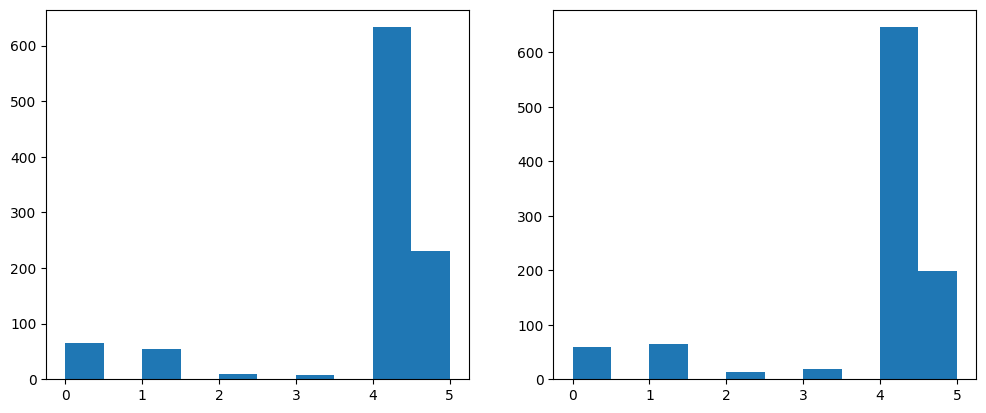

In [326]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

logits = scaled_action_plan_logits[100,0]
num_samples = (10, 100, 1_000, 10_000)[2]

actions_cat = Categorical(logits=torch.tensor(logits).unsqueeze(0).expand(num_samples, -1)).sample()
ax1.hist(actions_cat)

probs = logits + AGENT.generate_actions_noise(num_samples).numpy()
actions_gumbel = np.argmax(probs, axis=-1)
ax2.hist(actions_gumbel);

In [69]:
p = torch.tensor([0.3, 0.5]).to(torch.float32)
torch.softmax(p, dim=0), torch.softmax(p / 0.42, dim=0), torch.softmax(p / 0.1, dim=0)

(tensor([0.4502, 0.5498]), tensor([0.3832, 0.6168]), tensor([0.1192, 0.8808]))